In [104]:
# Imports
import numpy as np
import pandas as pd
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report

# Inline Plots
%matplotlib inline

In [105]:
# Data Read-In
temperature = pd.read_csv('./data/global_annual_mean_temp.csv', parse_dates=['Year'])
emissions = pd.read_csv('./data/co2-emissions.csv', parse_dates=['Year'])
sea_level = pd.read_csv('./data/epa-sea-level_csv.csv', parse_dates=['Year'])
sunspots = pd.read_csv('./data/sunspots.csv', parse_dates=['Date'])

In [106]:
# Drop unneeded columns
temperature = temperature.drop(columns=['No_Smoothing'])
emissions = emissions.drop(columns=['Entity', 'Code'])
sea_level = sea_level.drop(columns=['NOAA Adjusted Sea Level'])
sunspots = sunspots.drop(columns=['Unnamed: 0'])

In [117]:
# Adjust column names
temperature.columns = ['Year', 'Temperature Change']
emissions.columns = ['Year', 'Emissions']
sea_level.columns = ['Year', 'CSIRO Sea Level', 'Lower Error Bound', 'Upper Error Bound']
sunspots.columns = ['Year', 'Monthly Mean Sunspots']

In [125]:
# Convert years to datetime object
temperature['Year'] = pd.to_datetime(temperature['Year'], format='%Y')
emissions['Year'] = pd.to_datetime(emissions['Year'], format='%Y')
sea_level['Year'] = pd.to_datetime(sea_level['Year'], format='%Y')
sunspots['Year'] = pd.to_datetime(sunspots['Year'], format='%Y')

In [127]:
# Drop the month and day and keep the year
temperature['Year'] = temperature['Year'].dt.year
emissions['Year'] = emissions['Year'].dt.year
sea_level['Year'] = sea_level['Year'].dt.year
sunspots['Year'] = sunspots['Year'].dt.year

In [129]:
# Display info
display(temperature.info())
display(emissions.info())
display(sea_level.info())
sunspots.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year                143 non-null    int64  
 1   Temperature Change  143 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 2.4 KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31349 entries, 0 to 31348
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Year       31349 non-null  int64  
 1   Emissions  31349 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 490.0 KB


None

<class 'pandas.core.frame.DataFrame'>
Int64Index: 134 entries, 0 to 133
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               134 non-null    int64  
 1   CSIRO Sea Level    134 non-null    float64
 2   Lower Error Bound  134 non-null    float64
 3   Upper Error Bound  134 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 5.2 KB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3265 entries, 0 to 3264
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Year                   3265 non-null   int64  
 1   Monthly Mean Sunspots  3265 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 51.1 KB


In [130]:
# Drop na's
temperature = temperature.dropna()
emissions = emissions.dropna()
sea_level = sea_level.dropna()
sunspots = sunspots.dropna()

In [131]:
# Preview datasets
display(temperature.head())
display(emissions.head())
display(sea_level.head())
sunspots.head()

,Year,Temperature Change
0,1880,-0.10
1,1881,-0.13
2,1882,-0.17
3,1883,-0.20
4,1884,-0.24


,Year,Emissions
0,1949,14656.0
1,1950,84272.0
2,1951,91600.0
3,1952,91600.0
4,1953,106256.0


,Year,CSIRO Sea Level,Lower Error Bound,Upper Error Bound
0,1880,0.000000,-0.952756,0.952756
1,1881,0.220472,-0.732283,1.173228
2,1882,-0.440945,-1.346457,0.464567
3,1883,-0.232283,-1.129921,0.665354
4,1884,0.590551,-0.283465,1.464567


,Year,Monthly Mean Sunspots
0,1749,96.7
1,1749,104.3
2,1749,116.7
3,1749,92.8
4,1749,141.7


In [137]:
# Create plots
temperatures_plot = px.line(
    temperature,
    x='Year',
    y='Temperature Change',
    title='Temperature Change'
)

emissions_plot = px.line(
    emissions, x='Year',
    y='Emissions',
    title='Emissions Change'
)

sea_levels_plot = px.line(
    sea_level,
    x='Year',
    y='CSIRO Sea Level',
    title='Sea Level Change'
)

sunspots_plot = px.line(
    sunspots,
    x='Year',
    y='Monthly Mean Sunspots',
    title='Sunspots Change'
)

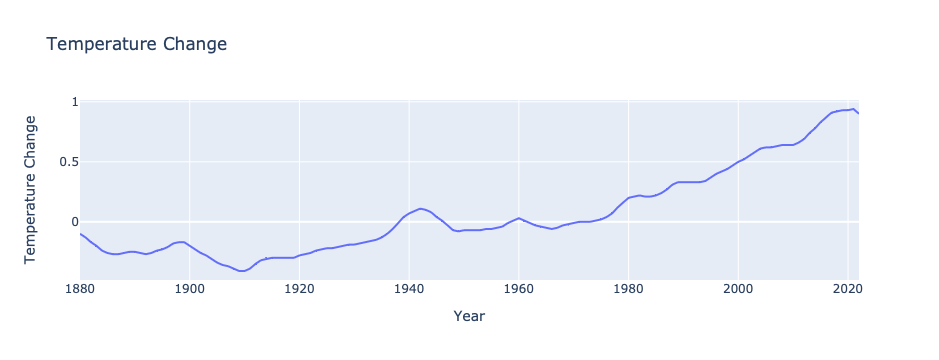

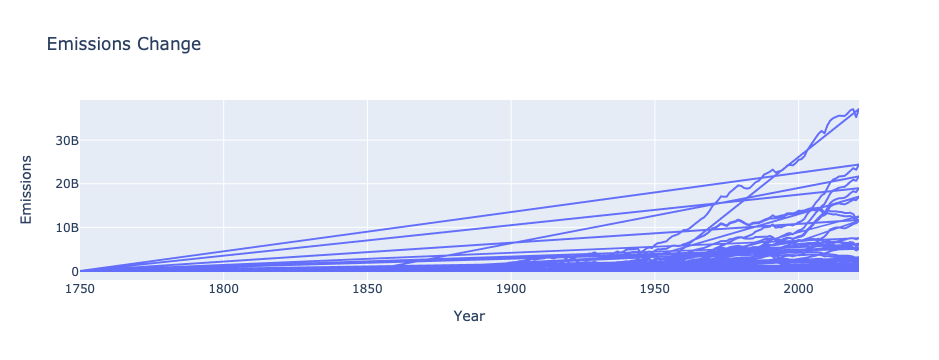

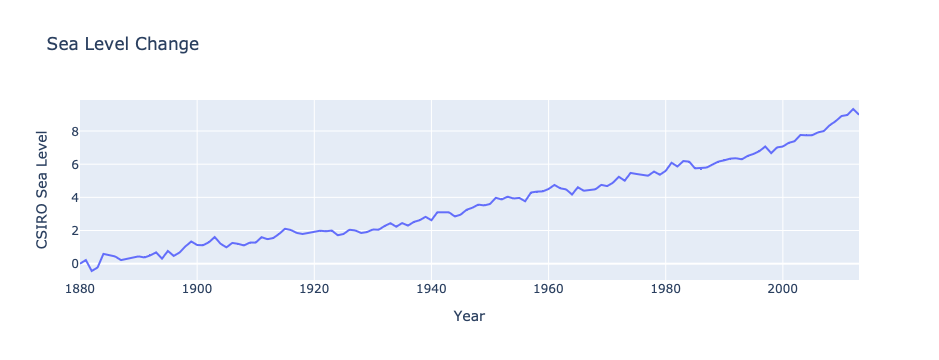

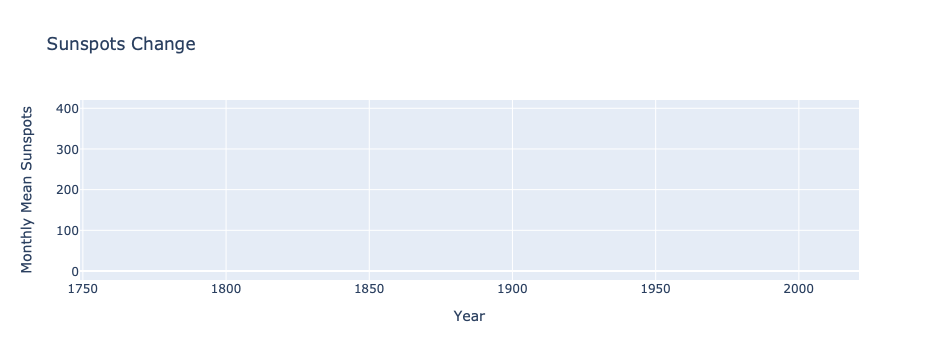

In [138]:
# Display plots
temperatures_plot.show()
emissions_plot.show()
sea_levels_plot.show()
sunspots_plot.show()

# Data Prep
---

In [189]:
# Concatenate datasets
combined_df = pd.concat([emissions, sea_level, sunspots, temperature], axis=0)

In [190]:
# Fill back na's
combined_df.fillna(method='bfill', inplace=True)

In [191]:
# Fill forward na's
combined_df.fillna(method='ffill', inplace=True)

In [192]:
# Display head & tail
display(combined_df.head())
combined_df.tail()

,Year,Emissions,CSIRO Sea Level,Lower Error Bound,Upper Error Bound,Monthly Mean Sunspots,Temperature Change
0,1949,14656.00,0.00,-0.95,0.95,96.70,-0.10
1,1950,84272.00,0.00,-0.95,0.95,96.70,-0.10
2,1951,91600.00,0.00,-0.95,0.95,96.70,-0.10
3,1952,91600.00,0.00,-0.95,0.95,96.70,-0.10
4,1953,106256.00,0.00,-0.95,0.95,96.70,-0.10


,Year,Emissions,CSIRO Sea Level,Lower Error Bound,Upper Error Bound,Monthly Mean Sunspots,Temperature Change
138,2018,11296114.00,8.98,8.62,9.34,10.40,0.92
139,2019,11296114.00,8.98,8.62,9.34,10.40,0.93
140,2020,11296114.00,8.98,8.62,9.34,10.40,0.93
141,2021,11296114.00,8.98,8.62,9.34,10.40,0.94
142,2022,11296114.00,8.98,8.62,9.34,10.40,0.90


In [193]:
# Prevent scientific numeric notation
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

In [194]:
# Get shape, info, & description
display(combined_df.shape)
display(combined_df.info())
combined_df.describe()

(34891, 7)

<class 'pandas.core.frame.DataFrame'>
Int64Index: 34891 entries, 0 to 142
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Year                   34891 non-null  int64  
 1   Emissions              34891 non-null  float64
 2   CSIRO Sea Level        34891 non-null  float64
 3   Lower Error Bound      34891 non-null  float64
 4   Upper Error Bound      34891 non-null  float64
 5   Monthly Mean Sunspots  34891 non-null  float64
 6   Temperature Change     34891 non-null  float64
dtypes: float64(6), int64(1)
memory usage: 2.1 MB


None

,Year,Emissions,CSIRO Sea Level,Lower Error Bound,Upper Error Bound,Monthly Mean Sunspots,Temperature Change
count,34891.00,34891.00,34891.00,34891.00,34891.00,34891.00,34891.00
mean,1932.17,342559891.98,0.89,-0.00,1.78,94.95,-0.10
std,69.71,1709700417.51,2.68,2.85,2.50,21.90,0.02
min,1749.00,0.00,-0.44,-1.35,0.46,0.00,-0.41
25%,1889.00,197856.00,0.00,-0.95,0.95,96.70,-0.10
50%,1952.00,5577778.00,0.00,-0.95,0.95,96.70,-0.10
75%,1988.00,33089584.00,0.00,-0.95,0.95,96.70,-0.10
max,2022.00,37123850000.00,9.33,8.99,9.66,398.20,0.94


In [195]:
# Set target
y = ['Temperature Change']

In [196]:
# Set features
X = list(set(list(combined_df.columns))-set(y))

In [197]:
# Set target value to y
y = combined_df[y].values

In [198]:
# Set features values to X
X = combined_df[X].values

In [199]:
# Create train, test, split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.27, random_state=72)

In [200]:
# Fit the scaler
scaler.fit(X)

StandardScaler()

In [201]:
# Transform the data
scaler.transform(X)

array([[-0.20035682, -0.33332579, -0.33283127,  0.24147229, -0.33310238,
         0.07992073],
       [-0.2003161 , -0.33332579, -0.33283127,  0.25581803, -0.33310238,
         0.07992073],
       [-0.20031182, -0.33332579, -0.33283127,  0.27016377, -0.33310238,
         0.07992073],
       ...,
       [-0.19375823,  3.02196987,  3.02519444,  1.26001981,  3.02354176,
        -3.8613486 ],
       [-0.19375823,  3.02196987,  3.02519444,  1.27436555,  3.02354176,
        -3.8613486 ],
       [-0.19375823,  3.02196987,  3.02519444,  1.28871129,  3.02354176,
        -3.8613486 ]])

# Baseline Model (Linear Regression)
---

In [202]:
# Instantiate linear regression model
lr_model = LinearRegression()

In [203]:
# Fit lr_model to the data
lr_model.fit(X_train, y_train)

LinearRegression()

In [204]:
# Make baseline training prediction
lr_train_prediction = lr_model.predict(X_train)

In [205]:
# Display outputs
display(np.sqrt(mean_squared_error(y_train,lr_train_prediction)))
(r2_score(y_train, lr_train_prediction))

0.023705926908128488

0.0152178077748506

In [206]:
# Make baseline test prediction
lr_test_prediction = lr_model.predict(X_test)

In [207]:
# Display outputs
display(np.sqrt(mean_squared_error(y_test, lr_test_prediction))) 
r2_score(y_test, lr_test_prediction)

0.027352304385173765

0.019304428705721244

# Test Model (Ridge Regression)
---

In [208]:
# Instantiate ridge regression model with normalize=True
rr_model = Ridge(alpha=0.3)

In [209]:
# Fit the ridge regression model to X_train & y_train
rr_model.fit(X_train, y_train)

/Users/d369/Software/miniconda3/envs/project2/lib/python3.9/site-packages/sklearn/linear_model/_ridge.py:216: LinAlgWarning:

Ill-conditioned matrix (rcond=2.9691e-24): result may not be accurate.



Ridge(alpha=0.3)

In [210]:
# Make ridge regression train prediction
rr_train_prediction = rr_model.predict(X_train)

In [211]:
# Display outputs
display(np.sqrt(mean_squared_error(y_train, rr_train_prediction)))
r2_score(y_train, rr_train_prediction)

0.02370592703611699

0.015217797141155787

In [212]:
# Make ridge regression test prediction
rr_test_prediction = rr_model.predict(X_test)

In [213]:
# Display outputs
display(np.sqrt(mean_squared_error(y_test, rr_test_prediction)))
r2_score(y_test, rr_test_prediction)

0.027352312279852506

0.01930386259052408

In [214]:
# Additional metrics
print("Mean Squared Error: %.2f" % mean_squared_error(y_test, rr_test_prediction))
print("Square Root: %.2f" % np.sqrt(mean_squared_error(y_test, rr_test_prediction)))
print("Rsquared: %.2f" % rr_model.score(X_test, y_test))

Mean Squared Error: 0.00
Square Root: 0.03
Rsquared: 0.02


In [215]:
train_pred_df = pd.DataFrame(rr_train_prediction)
test_pred_df = pd.DataFrame(rr_test_prediction)

In [216]:
train_pred_df.columns = ['X Predictions']
test_pred_df.columns = ['y Predictions']

In [217]:
train_pred_plot = px.line(train_pred_df, title='X Train Predictions')
test_pred_plot = px.line(test_pred_df, title='X Test Predictions')

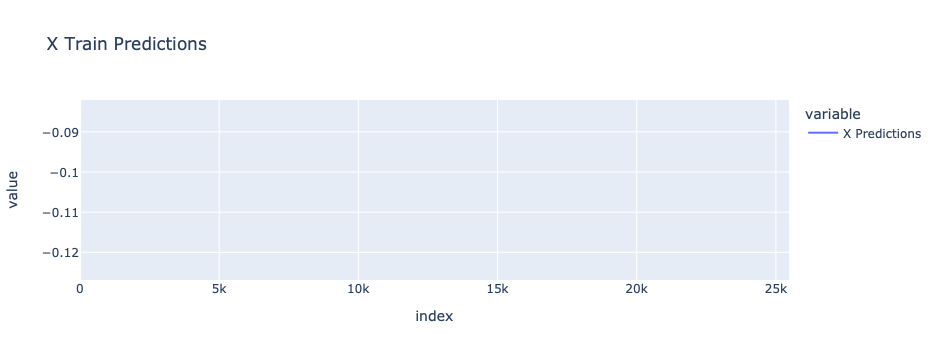

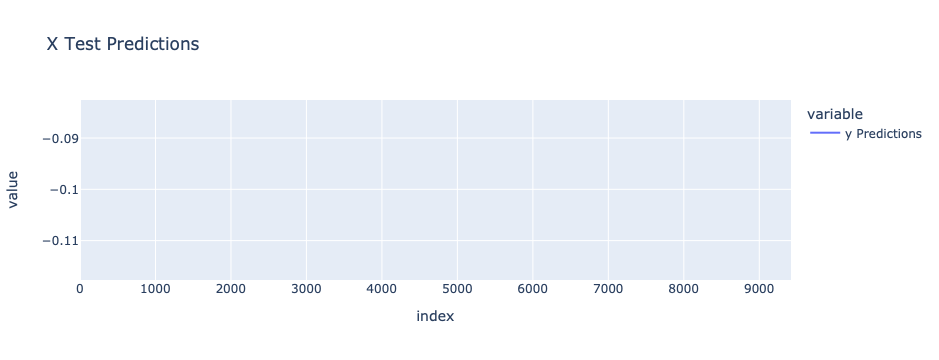

In [218]:
train_pred_plot.show()
test_pred_plot.show()